# Bank Marketing — exploração e qualidade dos dados

Este notebook inspeciona `bank-additional-full.csv`, valida seu esquema e documenta qualidade, conversão, diferenças observadas entre canais, comportamento por segmento, variação temporal e sinais de leakage.

In [1]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import seaborn as sns

# Funciona ao abrir o notebook pela raiz ou ao executar via nbconvert.
candidates = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
PROJECT_ROOT = next(path for path in candidates if (path / 'src' / 'adaptive_offers').exists())
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from adaptive_offers.config import DEFAULT_DATA_PATH, DEFAULT_REPORT_PATH
from adaptive_offers.data import load_bank_marketing, sha256_file, validate_schema, write_report

DATA_PATH = PROJECT_ROOT / 'data' / 'raw' / DEFAULT_DATA_PATH.name
ARTIFACTS = PROJECT_ROOT / 'artifacts'
ARTIFACTS.mkdir(exist_ok=True)
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f'{DATA_PATH} não existe. Execute `make data` (Kaggle) ou `make data-uci` antes do notebook.'
    )

df = load_bank_marketing(DATA_PATH)
report = validate_schema(df)
report['sha256'] = sha256_file(DATA_PATH)
report['source_file'] = str(DATA_PATH)
write_report(report, DEFAULT_REPORT_PATH)
print(f'Linhas: {len(df):,} | Colunas: {len(df.columns)} | SHA-256: {report["sha256"]}')

Linhas: 41,188 | Colunas: 21 | SHA-256: 74adfc578bf77a7ff4bb1ba4a9f8709d9e3c6907342959c2c8416847e0afb4d8


## Shape, tipos e qualidade

In [2]:
display(df.head())
display(df.dtypes.rename('dtype').to_frame())
quality = df.isna().sum().rename('missing').to_frame()
quality['n_unique'] = df.nunique(dropna=False)
quality['missing_pct'] = quality['missing'] / len(df)
display(quality)
print(f'Duplicatas completas: {df.duplicated().sum():,}')
display(df.describe(include='all').T)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


,dtype
age,int64
job,object
marital,object
education,object
default,object
housing,object
loan,object
contact,object
month,object
day_of_week,object


,missing,n_unique,missing_pct
age,0,78,0.0
job,0,12,0.0
marital,0,4,0.0
education,0,8,0.0
default,0,3,0.0
housing,0,3,0.0
loan,0,3,0.0
contact,0,2,0.0
month,0,10,0.0
day_of_week,0,5,0.0


Duplicatas completas: 12


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,41188.0,NaN,NaN,NaN,40.02406,10.42125,17.0,32.0,38.0,47.0,98.0
job,41188,12,admin.,10422,NaN,NaN,NaN,NaN,NaN,NaN,NaN
marital,41188,4,married,24928,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education,41188,8,university.degree,12168,NaN,NaN,NaN,NaN,NaN,NaN,NaN
default,41188,3,no,32588,NaN,NaN,NaN,NaN,NaN,NaN,NaN
housing,41188,3,yes,21576,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan,41188,3,no,33950,NaN,NaN,NaN,NaN,NaN,NaN,NaN
contact,41188,2,cellular,26144,NaN,NaN,NaN,NaN,NaN,NaN,NaN
month,41188,10,may,13769,NaN,NaN,NaN,NaN,NaN,NaN,NaN
day_of_week,41188,5,thu,8623,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Conversão, ação observada e desbalanceamento

Taxa de conversão global: 11.27%


,conversions,contacts,conversion_rate
contact,,,
cellular,3853,26144,0.147376
telephone,787,15044,0.052313


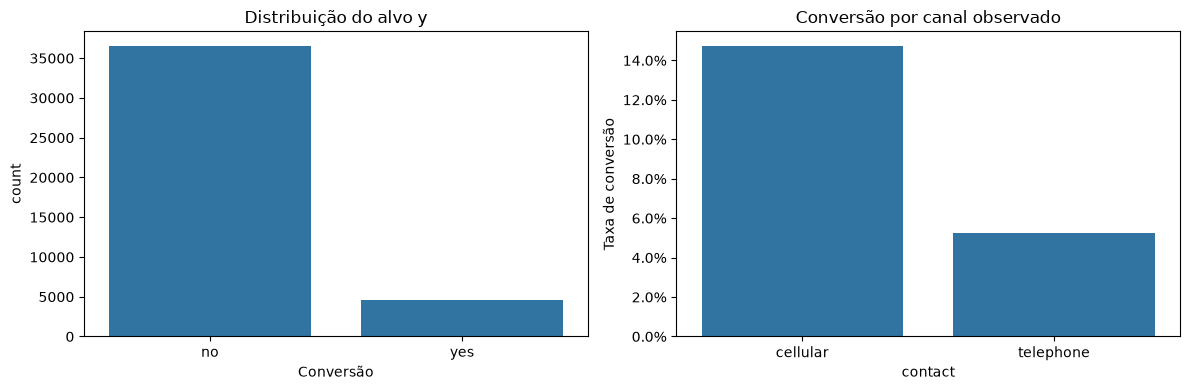

In [3]:
conversion = (df['y'] == 'yes').mean()
print(f'Taxa de conversão global: {conversion:.2%}')
by_contact = (
    df.groupby('contact', observed=True)['y']
      .agg(conversions=lambda s: (s == 'yes').sum(), contacts='size')
      .assign(conversion_rate=lambda t: t['conversions'] / t['contacts'])
)
display(by_contact)
by_contact.to_csv(ARTIFACTS / 'conversion_by_contact.csv')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=df, x='y', ax=axes[0])
axes[0].set_title('Distribuição do alvo y')
axes[0].set_xlabel('Conversão')
sns.barplot(data=by_contact.reset_index(), x='contact', y='conversion_rate', ax=axes[1])
axes[1].set_title('Conversão por canal observado')
axes[1].set_ylabel('Taxa de conversão')
axes[1].yaxis.set_major_formatter(PercentFormatter(1.0))
fig.tight_layout()
fig.savefig(ARTIFACTS / 'conversion_overview.png', dpi=150, bbox_inches='tight')
plt.show()

## Variável pós-contato: duração da ligação

`duration` está presente no arquivo, mas só é medida durante ou após a ligação. Como pode carregar informação sobre o resultado, esta análise registra o risco e compara o diagnóstico preditivo com e sem essa variável. A comparação é exploratória: uma métrica maior com `duration` não significa que ela esteja disponível no instante da decisão.

In [4]:
leakage = pd.DataFrame({
    'column': ['duration'],
    'reason': ['disponível somente após o contato; pode vazar o resultado'],
    'used_in_future_model': [False],
})
leakage.to_csv(ARTIFACTS / 'leakage_register.csv', index=False)
display(leakage)

,column,reason,used_in_future_model
0,duration,disponível somente após o contato; pode vazar ...,False


## Segmentos que mudam a conversão

As taxas abaixo são observacionais. `poutcome=success`, estudante/aposentado e os meses de baixo volume convertem muito acima da média. `default='yes'` quase não aparece. `campaign` conta o contato atual: a conversão cai conforme aumentam as tentativas.

default='yes': 3 linhas
pdays >= 999 (nunca contatado): 96.3%
Duplicatas exatas: 12


,column,unknown_rate,unknown_rows
0,job,0.008012,330
1,marital,0.001942,80
2,education,0.042027,1731
3,default,0.208726,8597
4,housing,0.024036,990
5,loan,0.024036,990


,job,conversions,contacts,conversion_rate
0,student,275,875,0.314286
1,retired,434,1720,0.252326
2,unemployed,144,1014,0.142012
3,admin.,1352,10422,0.129726
4,management,328,2924,0.112175
5,unknown,37,330,0.112121
6,technician,730,6743,0.108260
7,self-employed,149,1421,0.104856
8,housemaid,106,1060,0.100000
9,entrepreneur,124,1456,0.085165


,poutcome,conversions,contacts,conversion_rate
0,success,894,1373,0.651129
1,failure,605,4252,0.142286
2,nonexistent,3141,35563,0.088322


,month,conversions,contacts,conversion_rate
0,mar,276,546,0.505495
1,dec,89,182,0.489011
2,sep,256,570,0.449123
3,oct,315,718,0.438719
4,apr,539,2632,0.204787
5,aug,655,6178,0.106021
6,jun,559,5318,0.105115
7,nov,416,4101,0.101439
8,jul,649,7174,0.090466
9,may,886,13769,0.064347


,campaign_bin,conversions,contacts,conversion_rate
0,1,2300,17642,0.130371
1,2,1211,10570,0.114570
2,3,574,5341,0.107471
3,4-5,369,4250,0.086824
4,6+,186,3385,0.054948


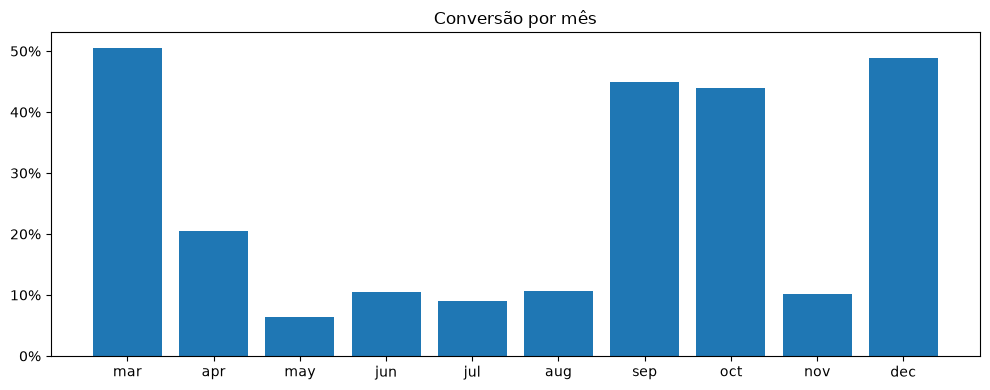

In [5]:
from adaptive_offers.eda import (
    campaign_fatigue,
    conversion_by,
    duration_leakage_comparison,
    macro_correlation,
    unknown_rates,
    channel_by_euribor,
    channel_by_month,
    channel_by_period,
)

print(f"default='yes': {(df['default'] == 'yes').sum()} linhas")
print(f"pdays >= 999 (nunca contatado): {(df['pdays'] >= 999).mean():.1%}")
print(f"Duplicatas exatas: {df.duplicated().sum()}")
display(unknown_rates(df))
display(conversion_by(df, 'job'))
display(conversion_by(df, 'poutcome'))
display(conversion_by(df, 'month'))
display(campaign_fatigue(df))

month = conversion_by(df, 'month')
month['month'] = pd.Categorical(month['month'], ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec'], ordered=True)
month = month.sort_values('month')
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(month['month'].astype(str), month['conversion_rate'])
ax.set_title('Conversão por mês')
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
fig.tight_layout()
fig.savefig(ARTIFACTS / 'conversion_by_month.png', dpi=150, bbox_inches='tight')
plt.show()

## Canal não é um efeito isolado

Celular converte cerca de três vezes mais que telefone na margem. O arquivo está ordenado de maio de 2008 a novembro de 2010, e o canal muda junto com o Euribor. A comparação dentro do período e da faixa de Euribor é o teste do confundimento: se o gap encolher, o baseline "sempre celular" está aprendendo a época da campanha, não só o canal.

,periodo,contact,conversions,contacts,conversion_rate
0,P5,cellular,2332,7245,0.321877
1,P5,telephone,208,993,0.209466
2,P3,telephone,88,670,0.131343
3,P4,cellular,865,7644,0.113161
4,P4,telephone,47,593,0.079258
5,P2,cellular,262,3687,0.071060
6,P3,cellular,394,7568,0.052061
7,P2,telephone,185,4550,0.040659
8,P1,telephone,259,8238,0.031440


,euribor_bin,contact,conversions,contacts,conversion_rate
0,"(0.633, 1.344]",cellular,2466,9432,0.261450
1,"(0.633, 1.344]",telephone,210,1111,0.189019
2,"(1.344, 4.857]",cellular,750,5988,0.125251
3,"(4.857, 4.961]",cellular,165,2349,0.070243
4,"(4.961, 5.045]",cellular,472,8375,0.056358
5,"(4.961, 5.045]",telephone,67,1416,0.047316
6,"(4.857, 4.961]",telephone,310,6993,0.044330
7,"(1.344, 4.857]",telephone,200,5524,0.036206


,contact,month,conversions,contacts,conversion_rate
0,cellular,mar,252,486,0.518519
1,telephone,mar,24,60,0.400000
2,cellular,apr,493,2445,0.201636
3,telephone,apr,46,187,0.245989
4,cellular,may,614,5518,0.111272
5,telephone,may,272,8251,0.032966
6,cellular,jun,349,820,0.425610
7,telephone,jun,210,4498,0.046687
8,cellular,jul,591,6096,0.096949
9,telephone,jul,58,1078,0.053803


,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
emp.var.rate,1.000000,0.775334,0.196041,0.972245,0.906970
cons.price.idx,0.775334,1.000000,0.058986,0.688230,0.522034
cons.conf.idx,0.196041,0.058986,1.000000,0.277686,0.100513
euribor3m,0.972245,0.688230,0.277686,1.000000,0.945154
nr.employed,0.906970,0.522034,0.100513,0.945154,1.000000


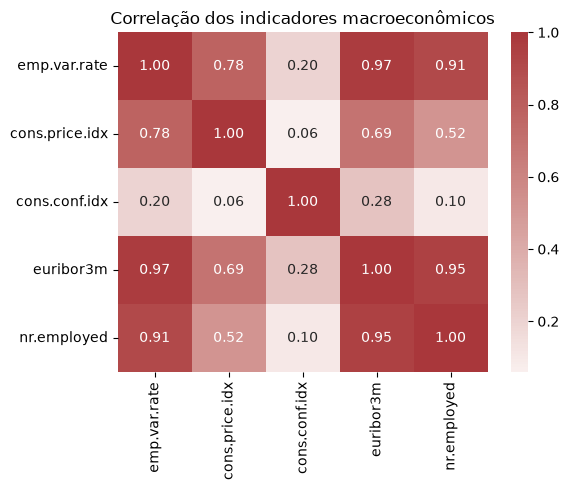

In [6]:
display(channel_by_period(df))
display(channel_by_euribor(df))
display(channel_by_month(df))
macro = macro_correlation(df)
display(macro)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(macro, annot=True, fmt='.2f', cmap='vlag', center=0, ax=ax)
ax.set_title('Correlação dos indicadores macroeconômicos')
fig.tight_layout()
fig.savefig(ARTIFACTS / 'macro_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

## Prova quantitativa do leakage de `duration`

O modelo abaixo é um diagnóstico de propensão no teste temporal. Ele não é a política servida. Incluir `duration` aumenta o AUC porque a duração só existe depois da ligação.

In [7]:
leakage_metrics = duration_leakage_comparison(df)
display(leakage_metrics)
leakage_metrics.to_csv(ARTIFACTS / 'duration_leakage_auc.csv', index=False)

,split,include_duration,test_roc_auc,test_pr_auc,test_rows
0,temporal,False,0.464346,0.339561,8238
1,temporal,True,0.533016,0.404227,8238
2,aleatorio,False,0.800785,0.464820,8238
3,aleatorio,True,0.942437,0.635600,8238
